In [1]:
import pandas as pd
pkl_file = "/disk3/hejp/00_thesis/4_predict_translation/data/processed/dataset_nt450_v3/train_pos_neg_merged_len_matched.pkl"
df = pd.read_pickle(pkl_file)

print("原始数据量:", df.shape)
print("所有列名:")
print(df.columns.tolist())
print(df['label_raw'].value_counts())
print(df['label_id'].value_counts())

原始数据量: (19158, 19)
所有列名:
['sample_id', 'protein_accession', 'transcript_accession', 'protein_len_aa', 'orf_seq', 'upstream_seq_50nt', 'downstream_seq_50nt', 'orf_nt_len', 'label_raw', 'protein_len_a', 'label_id', 'binary_label', 'orf_len', 'up_len', 'down_len', 'orf_bin', 'up_bin', 'down_bin', 'len_bin']
label_raw
ribotricer     9579
MS-|Ribo+      2208
MS++|Ribo+     1634
MS-|Ribo++     1613
MS+|Ribo+      1584
MS++|Ribo++    1297
MS+|Ribo++     1243
Name: count, dtype: int64
label_id
7    9579
5    2208
0    1634
6    1613
3    1584
1    1297
4    1243
Name: count, dtype: int64


In [ ]:
#在我们自己建立的数据集中测试#

In [9]:
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_test_baseline_v3/build_mipepid_fasta_from_pkl.py

原始数据量: (19158, 19)
label_raw
ribotricer     9579
MS-|Ribo+      2208
MS++|Ribo+     1634
MS-|Ribo++     1613
MS+|Ribo+      1584
MS++|Ribo++    1297
MS+|Ribo++     1243
Name: count, dtype: int64

完成！
筛选后数据量: (19158, 22)
FASTA: /disk3/hejp/00_thesis/4_predict_translation/results/result_baseline_v3/mipepid/mipepid_test/mipepid_input_MSpp_vs_rtorfs_30_150aa.fasta
标签表: /disk3/hejp/00_thesis/4_predict_translation/results/result_baseline_v3/mipepid/mipepid_test/mipepid_labels_MSpp_vs_rtorfs_30_150aa.tsv

原始标签分布:
label_raw
ribotricer     9579
MS-|Ribo+      2208
MS++|Ribo+     1634
MS-|Ribo++     1613
MS+|Ribo+      1584
MS++|Ribo++    1297
MS+|Ribo++     1243
Name: count, dtype: int64

最终二分类标签分布:
mipepid_label
0    9579
1    9579
Name: count, dtype: int64

label_raw 与 mipepid_label 对照:
mipepid_label     0     1
label_raw                
MS++|Ribo+        0  1634
MS++|Ribo++       0  1297
MS+|Ribo+         0  1584
MS+|Ribo++        0  1243
MS-|Ribo+         0  2208
MS-|Ribo++        0  1613
r

In [ ]:
###/usr/bin/shell###
cd /disk3/hejp/00_thesis/4_predict_translation/model/MiPepid
python ./src/mipepid.py \
  /disk3/hejp/00_thesis/4_predict_translation/results/result_baseline_v3/mipepid/mipepid_test/mipepid_input_MSpp_vs_rtorfs_30_150aa.fasta \
  /disk3/hejp/00_thesis/4_predict_translation/results/result_baseline_v3/mipepid/mipepid_test/mipepid_output_MSpp_vs_rtorfs_30_150aa.csv

Begin writing the output file: /disk3/hejp/00_thesis/4_predict_translation/results/result_baseline/mipepid/mipepid_test/mipepid_output_MSpp_vs_rtorfs_30_150aa.csv
Traceback (most recent call last):
  File "/disk3/hejp/00_thesis/4_predict_translation/model/MiPepid/src/mipepid.py", line 53, in <module>
    MiPepid(input_fname, output_fname)
  File "/disk3/hejp/00_thesis/4_predict_translation/model/MiPepid/src/mipepid.py", line 16, in MiPepid
    logr, threshold = ML.load_model()
  File "/disk3/hejp/00_thesis/4_predict_translation/model/MiPepid/src/ML.py", line 78, in load_model
    f = open(model_fname, 'rb')
FileNotFoundError: [Errno 2] No such file or directory: './src/model/model.pkl'


In [10]:
test=pd.read_csv('/disk3/hejp/00_thesis/4_predict_translation/results/result_baseline_v3/mipepid/mipepid_test/mipepid_output_MSpp_vs_rtorfs_30_150aa.csv')
label=pd.read_table('/disk3/hejp/00_thesis/4_predict_translation/results/result_baseline_v3/mipepid/mipepid_test/mipepid_labels_MSpp_vs_rtorfs_30_150aa.tsv')
print(test.head())
print(test['classification'].value_counts())
print(test.shape)
print(label.head())
print(label.shape)

                                          sORF_ID  \
0  ENST00000520378_151139086_151140165_375_0_ORF1   
1  ENST00000520378_151139086_151140165_375_0_ORF2   
2  ENST00000520378_151139086_151140165_375_0_ORF3   
3  ENST00000520378_151139086_151140165_375_0_ORF4   
4  ENST00000520378_151139086_151140165_375_0_ORF5   

                                            sORF_seq  \
0  ATGGGGTGCGGGTGGAAGAATGATTTCATTCACCTGTGTGCTCGTT...   
1  ATGGCACTCCAGGTTAGCCTGTGGGCTGACACCTTACCCTGCTCTT...   
2               ATGGGTGAGGTGTCAACTCTGTGGACTGCCAGATAG   
3  ATGATTTCATTCACCTGTGTGCTCGTTCAGGTTATTTCCTGGATAT...   
4                                 ATGCTGGGCTCGTGCTAG   

                  transcript_DNA_sequence_ID  start_at  end_at classification  \
0  ENST00000520378_151139086_151140165_375_0       133     378         coding   
1  ENST00000520378_151139086_151140165_375_0       196     378         coding   
2  ENST00000520378_151139086_151140165_375_0       343     378         coding   
3  ENST00000520378_1

In [11]:
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_test_baseline_v3/evaluate_mipepid.py

MiPepid output:
                                          sORF_ID  ... probability
0  ENST00000520378_151139086_151140165_375_0_ORF1  ...    0.955748
1  ENST00000520378_151139086_151140165_375_0_ORF2  ...    0.895559
2  ENST00000520378_151139086_151140165_375_0_ORF3  ...    0.990863
3  ENST00000520378_151139086_151140165_375_0_ORF4  ...    0.987623
4  ENST00000520378_151139086_151140165_375_0_ORF5  ...    0.999457

[5 rows x 7 columns]
Index(['sORF_ID', 'sORF_seq', 'transcript_DNA_sequence_ID', 'start_at',
       'end_at', 'classification', 'probability'],
      dtype='object')

Label table:
                                    fasta_id  ...                                        mipepid_seq
0  ENST00000520378_151139086_151140165_375_0  ...  ATGAAGGGCTTTGGCAGTGACAAGGAGGCCATACTGGACATAATCA...
1  ENST00000650977_145699957_145700151_195_0  ...  ATGAAGAGAGCAACAGAATCTTATACTTACAATCAGTGTCATGGTA...
2                           sample_0024666_0  ...  ATGGCGATGGTGATGGCAGCAGTTACTCGCACAACCCCAGTTAAGC.

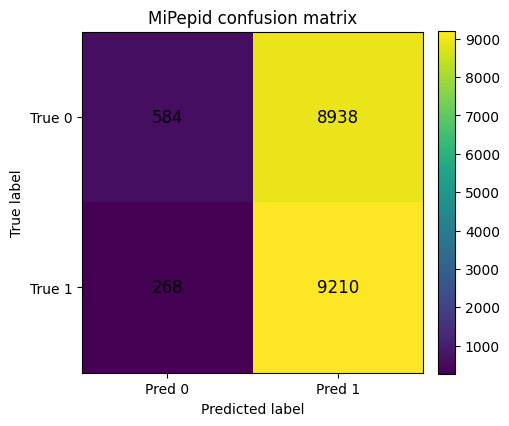

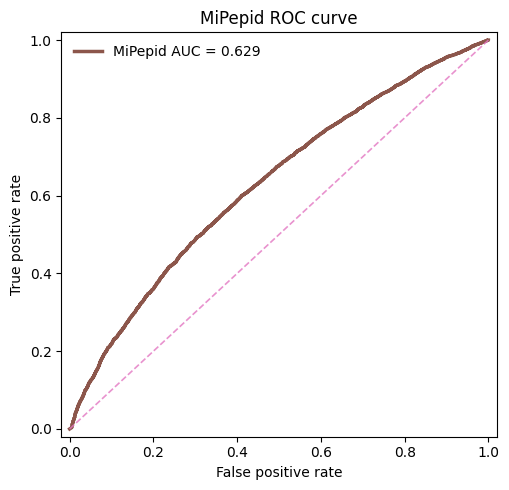

Saved to: /disk3/hejp/00_thesis/4_predict_translation/results/result_baseline_v3/mipepid/mipepid_test/figures_pdf
AUC: 0.6288
Confusion matrix:
[[ 584 8938]
 [ 268 9210]]


In [1]:
###展示混淆矩阵以及roc曲线###
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

# ===== 路径 =====
base_dir = "/disk3/hejp/00_thesis/4_predict_translation/results/result_baseline_v3/mipepid/mipepid_test"
in_file = os.path.join(base_dir, "mipepid_eval_merged_MSpp_vs_rtorfs_30_150aa.tsv")

fig_dir = os.path.join(base_dir, "figures_pdf")
os.makedirs(fig_dir, exist_ok=True)

# ===== 读入数据 =====
df = pd.read_csv(in_file, sep="\t")

y_true = df["mipepid_label"].astype(int).values

# 混淆矩阵：优先使用 MiPepid 原始 classification
if "pred_label_by_classification" in df.columns:
    y_pred = df["pred_label_by_classification"].astype(int).values
else:
    y_pred = df["classification"].map({"noncoding": 0, "coding": 1}).astype(int).values

# ROC：优先使用 coding_score
score_col = "coding_score" if "coding_score" in df.columns else "probability"
y_score = pd.to_numeric(df[score_col], errors="coerce").fillna(0).values

# ===== 1. Confusion matrix =====
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

plt.figure(figsize=(5.2, 5.0))
im = plt.imshow(cm, cmap="viridis")
plt.colorbar(im, fraction=0.046, pad=0.04)

plt.xticks([0, 1], ["Pred 0", "Pred 1"])
plt.yticks([0, 1], ["True 0", "True 1"])
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("MiPepid confusion matrix")

for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=12, color="black")

plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "MiPepid_confusion_matrix.pdf"), format="pdf", bbox_inches="tight")
plt.show()
plt.close()

# ===== 2. ROC curve =====
fpr, tpr, _ = roc_curve(y_true, y_score)
auc = roc_auc_score(y_true, y_score)

plt.figure(figsize=(5.2, 5.0))
plt.plot(fpr, tpr, lw=2.5, color="#8c564b", label=f"MiPepid AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "--", lw=1.2, color="#e377c2", alpha=0.8)

plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("MiPepid ROC curve")
plt.legend(loc="upper left", frameon=False)
plt.tight_layout()

plt.savefig(os.path.join(fig_dir, "MiPepid_ROC_curve.pdf"), format="pdf", bbox_inches="tight")
plt.show()
plt.close()

print("Saved to:", fig_dir)
print("AUC:", round(auc, 4))
print("Confusion matrix:")
print(cm)

In [13]:
###sOCP###
#用sOCP环境#
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_test_baseline_v3/build_sOCP_fasta_from_pkl.py

原始数据量: (19158, 19)
所有列名:
['sample_id', 'protein_accession', 'transcript_accession', 'protein_len_aa', 'orf_seq', 'upstream_seq_50nt', 'downstream_seq_50nt', 'orf_nt_len', 'label_raw', 'protein_len_a', 'label_id', 'binary_label', 'orf_len', 'up_len', 'down_len', 'orf_bin', 'up_bin', 'down_bin', 'len_bin']

原始 label_raw 分布:
label_raw
ribotricer     9579
MS-|Ribo+      2208
MS++|Ribo+     1634
MS-|Ribo++     1613
MS+|Ribo+      1584
MS++|Ribo++    1297
MS+|Ribo++     1243
Name: count, dtype: int64

原始 label_id 分布:
label_id
7    9579
5    2208
0    1634
6    1613
3    1584
1    1297
4    1243
Name: count, dtype: int64

去掉 MS-|Ribo- 并定义二分类标签后:
label_raw
ribotricer     9579
MS-|Ribo+      2208
MS++|Ribo+     1634
MS-|Ribo++     1613
MS+|Ribo+      1584
MS++|Ribo++    1297
MS+|Ribo++     1243
Name: count, dtype: int64

socp_label 分布:
socp_label
0    9579
1    9579
Name: count, dtype: int64

长度筛选 30-150 aa 后数据量: (19158, 20)
label_raw
ribotricer     9579
MS-|Ribo+      2208
MS++|Ribo+     1634


In [ ]:
###sOCP###
#用sOCP环境#
cd /disk3/hejp/00_thesis/4_predict_translation/model/sOCP
python PredictingCodingPotential.py \
-i /disk3/hejp/00_thesis/4_predict_translation/results/result_baseline_v3/sOCP/sOCP_test/sOCP_input_MSpp_vs_rtorfs_30_150aa_with_up3nt.fasta \
-o /disk3/hejp/00_thesis/4_predict_translation/results/result_baseline_v3/sOCP/sOCP_test/output_with_up3nt \
-m ./HumanModel


In [16]:
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_test_baseline_v3/evaluate_sOCP.py \
  --score_file /disk3/hejp/00_thesis/4_predict_translation/results/result_baseline_v3/sOCP/sOCP_test/output_with_up3nt.score.tsv \
  --label_file /disk3/hejp/00_thesis/4_predict_translation/results/result_baseline_v3/sOCP/sOCP_test/sOCP_labels_MSpp_vs_rtorfs_30_150aa_with_up3nt.tsv \
  --outdir /disk3/hejp/00_thesis/4_predict_translation/results/result_baseline_v3/sOCP/sOCP_test/evaluation_ssimple \
  --threshold 0.5

合并后数据量: (19100, 17)
没有 sOCP 预测结果的数量: 0

指标:
n: 19100
positive: 9537
negative: 9563
threshold: 0.5
roc_auc: 0.48943988065392763
pr_auc: 0.46207565463435574
accuracy: 0.48984293193717277
balanced_accuracy: 0.4897062883184422
precision: 0.4864404559151055
recall: 0.3893257837894516
f1: 0.43249854397204424
mcc: -0.021015146760649715
tn: 5643
fp: 3920
fn: 5824
tp: 3713

Confusion matrix:
[[5643 3920]
 [5824 3713]]

输出文件:
/disk3/hejp/00_thesis/4_predict_translation/results/result_baseline_v3/sOCP/sOCP_test/evaluation_ssimple/socp_score_with_label.tsv
/disk3/hejp/00_thesis/4_predict_translation/results/result_baseline_v3/sOCP/sOCP_test/evaluation_ssimple/socp_metrics.tsv
/disk3/hejp/00_thesis/4_predict_translation/results/result_baseline_v3/sOCP/sOCP_test/evaluation_ssimple/socp_report.txt


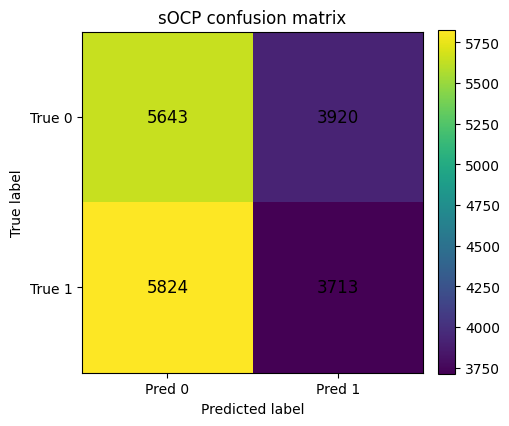

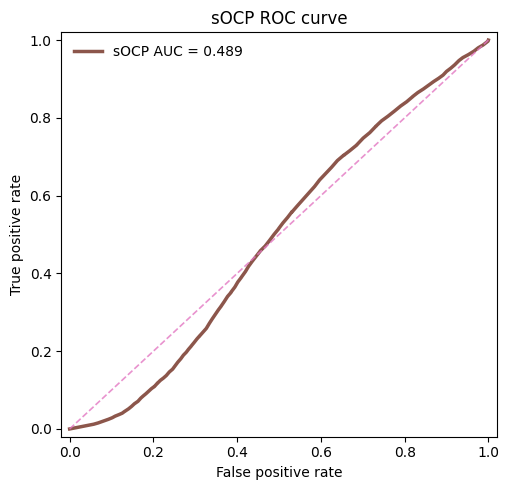

Saved to: /disk3/hejp/00_thesis/4_predict_translation/results/result_baseline_v3/sOCP/sOCP_test/evaluation_ssimple/figures_pdf
AUC: 0.4894
Confusion matrix:
[[5643 3920]
 [5824 3713]]


In [2]:
###展示混淆矩阵以及roc曲线###
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

# ===== 路径 =====
base_dir = "/disk3/hejp/00_thesis/4_predict_translation/results/result_baseline_v3/sOCP/sOCP_test/evaluation_ssimple"
in_file = os.path.join(base_dir, "socp_score_with_label.tsv")

fig_dir = os.path.join(base_dir, "figures_pdf")
os.makedirs(fig_dir, exist_ok=True)

# ===== 读入数据 =====
df = pd.read_csv(in_file, sep="\t")

y_true = df["socp_label"].astype(int).values
y_pred = df["socp_pred"].astype(int).values
y_score = pd.to_numeric(df["socp_score"], errors="coerce").fillna(0).values

# ===== 1. Confusion matrix =====
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

plt.figure(figsize=(5.2, 5.0))
im = plt.imshow(cm, cmap="viridis")
plt.colorbar(im, fraction=0.046, pad=0.04)

plt.xticks([0, 1], ["Pred 0", "Pred 1"])
plt.yticks([0, 1], ["True 0", "True 1"])
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("sOCP confusion matrix")

for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=12, color="black")

plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "sOCP_confusion_matrix.pdf"), format="pdf", bbox_inches="tight")
plt.show()
plt.close()

# ===== 2. ROC curve =====
fpr, tpr, _ = roc_curve(y_true, y_score)
auc = roc_auc_score(y_true, y_score)

plt.figure(figsize=(5.2, 5.0))
plt.plot(fpr, tpr, lw=2.5, color="#8c564b", label=f"sOCP AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "--", lw=1.2, color="#e377c2", alpha=0.8)

plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("sOCP ROC curve")
plt.legend(loc="upper left", frameon=False)
plt.tight_layout()

plt.savefig(os.path.join(fig_dir, "sOCP_ROC_curve.pdf"), format="pdf", bbox_inches="tight")
plt.show()
plt.close()

print("Saved to:", fig_dir)
print("AUC:", round(auc, 4))
print("Confusion matrix:")
print(cm)

In [17]:
###DeepCPP###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_test_baseline_v3/build_deepcpp_fasta_from_pkl.py

原始数据量: (19158, 19)
所有列名:
['sample_id', 'protein_accession', 'transcript_accession', 'protein_len_aa', 'orf_seq', 'upstream_seq_50nt', 'downstream_seq_50nt', 'orf_nt_len', 'label_raw', 'protein_len_a', 'label_id', 'binary_label', 'orf_len', 'up_len', 'down_len', 'orf_bin', 'up_bin', 'down_bin', 'len_bin']

原始 label_raw 分布:
label_raw
ribotricer     9579
MS-|Ribo+      2208
MS++|Ribo+     1634
MS-|Ribo++     1613
MS+|Ribo+      1584
MS++|Ribo++    1297
MS+|Ribo++     1243
Name: count, dtype: int64

原始 label_id 分布:
label_id
7    9579
5    2208
0    1634
6    1613
3    1584
1    1297
4    1243
Name: count, dtype: int64

去掉 MS-|Ribo- 并定义二分类标签后:
label_raw
ribotricer     9579
MS-|Ribo+      2208
MS++|Ribo+     1634
MS-|Ribo++     1613
MS+|Ribo+      1584
MS++|Ribo++    1297
MS+|Ribo++     1243
Name: count, dtype: int64

deepcpp_label 分布:
deepcpp_label
0    9579
1    9579
Name: count, dtype: int64

长度筛选 30-150 aa 后数据量: (19158, 20)
label_raw
ribotricer     9579
MS-|Ribo+      2208
MS++|Ribo+    

In [ ]:
###在shell 中运行
conda activate deepcpp
cd /disk3/hejp/00_thesis/4_predict_translation/model/DeepCPP/code
python
import utils_lncRNA
from utils_lncRNA import test_model
test_model('../input_files/','../output_files/',
           'DeepCPP_input_MSpp_vs_rtorfs_30_150aa_upstream_ORF_downstream_v3.fasta','human','sorf')



In [19]:
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_test_baseline_v3/evaluate_DeepCPP_fixed.py \
  --pred_file /disk3/hejp/00_thesis/4_predict_translation/results/result_baseline_v3/DeepCPP/DeepCPP_test/predict_results.csv \
  --label_file /disk3/hejp/00_thesis/4_predict_translation/results/result_baseline_v3/DeepCPP/DeepCPP_test/DeepCPP_labels_MSpp_vs_rtorfs_30_150aa_upstream_ORF_downstream.tsv \
  --outdir /disk3/hejp/00_thesis/4_predict_translation/results/result_baseline_v3/DeepCPP/DeepCPP_test/evaluate

DeepCPP prediction shape: (19158, 3)

DeepCPP label distribution:
deepcpp_label
Noncoding    13884
Coding        5274
Name: count, dtype: int64

DeepCPP binary prediction distribution:
deepcpp_pred
0    13884
1     5274
Name: count, dtype: int64

Ground-truth label column used: label_raw_inferred_MSpp_vs_rtorfs

Ground-truth label distribution before merge:
true_label
1.0     2931
NaN    16227
Name: count, dtype: int64

合并后数据量: (19158, 24)
没有 DeepCPP 预测结果的数量: 0
去掉缺失 true_label 或 DeepCPP 预测后的数据量: 19158 -> 2931
只保留 true_label 为 0/1 的数据量: 2931 -> 2931
/home/hejp/anaconda3/envs/smorf_lmm/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")

指标:
n: 2931
positive: 2931
negative: 0
pred_positive: 839
pred_negative: 2092
accuracy: 0.2862504264756056
balanced_accuracy: 0.2862504264756056
precision: 1.0
recall: 0.2862504264756056
f1: 0.4450928381962865
mcc: 0.0
tn: 0
fp: 0

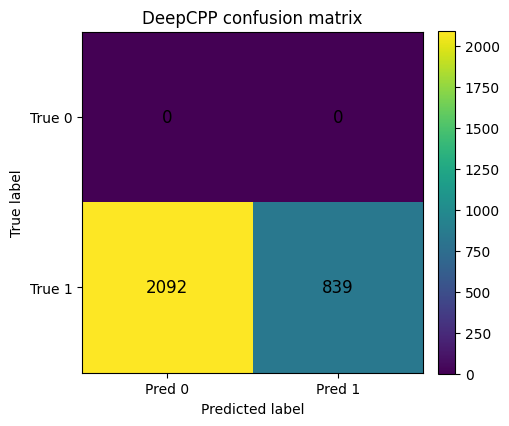

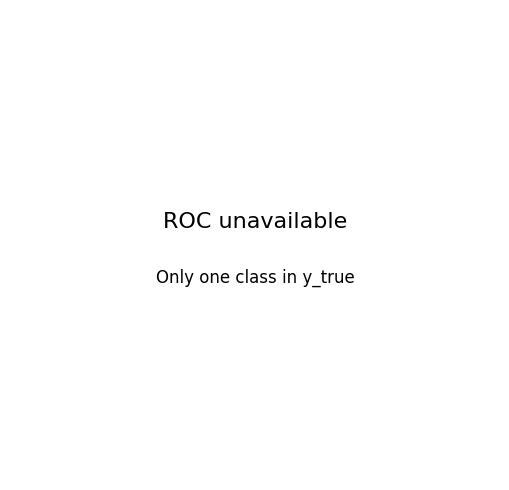

Saved to: /disk3/hejp/00_thesis/4_predict_translation/results/result_baseline_v3/DeepCPP/DeepCPP_test/evaluate/figures_pdf
AUC: nan
Confusion matrix:
[[   0    0]
 [2092  839]]
Label counts:
1    2931
Name: count, dtype: int64


In [3]:
###展示混淆矩阵以及roc曲线###
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

# ===== 路径 =====
base_dir = "/disk3/hejp/00_thesis/4_predict_translation/results/result_baseline_v3/DeepCPP/DeepCPP_test/evaluate"
in_file = os.path.join(base_dir, "deepcpp_pred_with_label.tsv")

fig_dir = os.path.join(base_dir, "figures_pdf")
os.makedirs(fig_dir, exist_ok=True)

# ===== 读入数据 =====
df = pd.read_csv(in_file, sep="\t")

y_true = df["true_label"].astype(int).values
y_pred = df["deepcpp_pred"].astype(int).values

# 如果以后 DeepCPP 输出里有 score/probability 列，会自动用于 ROC
score_candidates = ["deepcpp_score", "score", "prob", "probability", "coding_score", "y_score"]
score_col = next((c for c in score_candidates if c in df.columns), None)

# ===== 1. Confusion matrix =====
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

plt.figure(figsize=(5.2, 5.0))
im = plt.imshow(cm, cmap="viridis")
plt.colorbar(im, fraction=0.046, pad=0.04)

plt.xticks([0, 1], ["Pred 0", "Pred 1"])
plt.yticks([0, 1], ["True 0", "True 1"])
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("DeepCPP confusion matrix")

for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=12, color="black")

plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "DeepCPP_confusion_matrix.pdf"), format="pdf", bbox_inches="tight")
plt.show()
plt.close()

# ===== 2. ROC curve =====
roc_pdf = os.path.join(fig_dir, "DeepCPP_ROC_curve.pdf")

if len(np.unique(y_true)) < 2:
    plt.figure(figsize=(5.2, 5.0))
    plt.text(
        0.5, 0.55,
        "ROC unavailable",
        ha="center", va="center", fontsize=16
    )
    plt.text(
        0.5, 0.43,
        "Only one class in y_true",
        ha="center", va="center", fontsize=12
    )
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(roc_pdf, format="pdf", bbox_inches="tight")
    plt.show()
    plt.close()
    auc = np.nan

elif score_col is None:
    # 没有连续 score 时，用 0/1 预测值作为粗略 score，不推荐正式汇报
    y_score = y_pred.astype(float)
    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc = roc_auc_score(y_true, y_score)

    plt.figure(figsize=(5.2, 5.0))
    plt.plot(fpr, tpr, lw=2.5, color="#8c564b", label=f"DeepCPP AUC = {auc:.3f}")
    plt.plot([0, 1], [0, 1], "--", lw=1.2, color="#e377c2", alpha=0.8)
    plt.xlim([-0.02, 1.02])
    plt.ylim([-0.02, 1.02])
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title("DeepCPP ROC curve")
    plt.legend(loc="upper left", frameon=False)
    plt.tight_layout()
    plt.savefig(roc_pdf, format="pdf", bbox_inches="tight")
    plt.show()
    plt.close()

else:
    y_score = pd.to_numeric(df[score_col], errors="coerce").fillna(0).values
    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc = roc_auc_score(y_true, y_score)

    plt.figure(figsize=(5.2, 5.0))
    plt.plot(fpr, tpr, lw=2.5, color="#8c564b", label=f"DeepCPP AUC = {auc:.3f}")
    plt.plot([0, 1], [0, 1], "--", lw=1.2, color="#e377c2", alpha=0.8)
    plt.xlim([-0.02, 1.02])
    plt.ylim([-0.02, 1.02])
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title("DeepCPP ROC curve")
    plt.legend(loc="upper left", frameon=False)
    plt.tight_layout()
    plt.savefig(roc_pdf, format="pdf", bbox_inches="tight")
    plt.show()
    plt.close()

print("Saved to:", fig_dir)
print("AUC:", auc)
print("Confusion matrix:")
print(cm)
print("Label counts:")
print(pd.Series(y_true).value_counts().sort_index())

In [ ]:
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_test_baseline_v3/gencode_baseline_scripts/filter_gencode_external_by_openprot_cdhit.py \
  --input_table /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/gencode_pos_ribotricer_neg1w_merged.csv.gz \
  --openprot_fasta /disk3/hejp/00_thesis/4_predict_translation/dataset/openprot/ensembl/human-openprot-2_2-altprots+isoforms-GRCh38.106.fasta \
  --out_table /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/gencode_pos_ribotricer_neg1w_merged_cdhit80_noOpenProt.csv.gz \
  --outdir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/cdhit_openprot_filter_c80 \
  --id_col sample_id \
  --orf_col orf_seq \
  --label_col label_raw \
  --pos_label gencode \
  --identity 0.8 \
  --threads 32 \
  --cdhit_bin cd-hit


Running CD-HIT: cd-hit -i /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/cdhit_openprot_filter_c80/openprot_plus_input_table_aa.fasta -o /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/cdhit_openprot_filter_c80/cdhit_c0.80 -c 0.8 -n 5 -d 0 -T 32 -M 0
Program: CD-HIT, V4.8.1 (+OpenMP), Apr 24 2025, 22:00:32
Command: cd-hit -i
         /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/cdhit_openprot_filter_c80/openprot_plus_input_table_aa.fasta
         -o
         /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/cdhit_openprot_filter_c80/cdhit_c0.80
         -c 0.8 -n 5 -d 0 -T 32 -M 0

Started: Thu Jul  9 09:43:54 2026
                            Output                              
----------------------------------------------------------------
total seq

In [ ]:
###为了检查sOCP在gencode中效果好，是不是因为gencode与Refprot的重合比较多###
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_test_baseline_v3/gencode_baseline_scripts/filter_gencode_only_by_openprot_cdhit.py \
  --input_table /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/gencode_pos_ribotricer_neg1w_merged.csv.gz \
  --openprot_fasta /disk3/hejp/00_thesis/4_predict_translation/dataset/openprot/ensembl/human-openprot-2_2-refprots+altprots+isoforms-GRCh38.106-uniprot2022_06_01.fasta \
  --out_table /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/cdhit_allof_openprot_filter_c80_gencodeOnly/gencode_pos_ribotricer_neg1w_merged_cdhit80_noAllOpenProt.csv.gz \
  --outdir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/cdhit_allof_openprot_filter_c80_gencodeOnly \
  --id_col sample_id \
  --orf_col orf_seq \
  --label_col label_raw \
  --pos_label gencode \
  --identity 0.8 \
  --threads 32 \
  --cdhit_bin cd-hit

Input rows: 16178
GENCODE rows to filter: 6178
Non-GENCODE rows kept unchanged: 10000

Input label distribution:
label_raw
ribotricer    10000
gencode        6178

Running CD-HIT: cd-hit -i /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/cdhit_allof_openprot_filter_c80_gencodeOnly/openprot_plus_gencode_only_aa.fasta -o /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/cdhit_allof_openprot_filter_c80_gencodeOnly/cdhit_gencodeOnly_c0.80 -c 0.8 -n 5 -d 0 -T 32 -M 0
Program: CD-HIT, V4.8.1 (+OpenMP), Apr 24 2025, 22:00:32
Command: cd-hit -i
         /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/cdhit_allof_openprot_filter_c80_gencodeOnly/openprot_plus_gencode_only_aa.fasta
         -o
         /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/cdhit_allof_openp

In [4]:
!cat /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/cdhit_allof_openprot_filter_c80_gencodeOnly/cdhit_gencode_only_filter_summary.tsv

input_rows	input_gencode_rows	input_non_gencode_rows_kept_unchanged	gencode_rows_with_valid_aa	gencode_rows_invalid_aa_kept_not_compared	openprot_records	cdhit_identity	removed_gencode_similar_to_openprot	removed_gencode_duplicates	output_rows	output_gencode_rows	output_non_gencode_rows	out_table
16178	6178	10000	6178	0	682984	0.8	1650	57	14471	4471	10000	/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/cdhit_allof_openprot_filter_c80_gencodeOnly/gencode_pos_ribotricer_neg1w_merged_cdhit80_noAllOpenProt.csv.gz


In [ ]:
  
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_test_baseline_v3/gencode_baseline_scripts/filter_gencode_only_by_openprot_cdhit.py \
  --input_table /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/gencode_pos_ribotricer_neg1w_merged.csv.gz \
  --openprot_fasta /disk3/hejp/00_thesis/4_predict_translation/dataset/openprot/ensembl/human-openprot-2_2-altprots+isoforms-GRCh38.106.fasta \
  --out_table /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/gencode_pos_ribotricer_neg1w_merged_cdhit80_noOpenProt.csv.gz \
  --outdir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/cdhit_openprot_filter_c80_gencodeOnly \
  --id_col sample_id \
  --orf_col orf_seq \
  --label_col label_raw \
  --pos_label gencode \
  --identity 0.8 \
  --threads 32 \
  --cdhit_bin cd-hit

Input rows: 16178
GENCODE rows to filter: 6178
Non-GENCODE rows kept unchanged: 10000

Input label distribution:
label_raw
ribotricer    10000
gencode        6178

Running CD-HIT: cd-hit -i /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/cdhit_openprot_filter_c80_gencodeOnly/openprot_plus_gencode_only_aa.fasta -o /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/cdhit_openprot_filter_c80_gencodeOnly/cdhit_gencodeOnly_c0.80 -c 0.8 -n 5 -d 0 -T 32 -M 0
Program: CD-HIT, V4.8.1 (+OpenMP), Apr 24 2025, 22:00:32
Command: cd-hit -i
         /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/cdhit_openprot_filter_c80_gencodeOnly/openprot_plus_gencode_only_aa.fasta
         -o
         /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/cdhit_openprot_filter_c80_gencodeOn

In [6]:
!cat /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/cdhit_openprot_filter_c80_gencodeOnly/cdhit_gencode_only_filter_summary.tsv

input_rows	input_gencode_rows	input_non_gencode_rows_kept_unchanged	gencode_rows_with_valid_aa	gencode_rows_invalid_aa_kept_not_compared	openprot_records	cdhit_identity	removed_gencode_similar_to_openprot	removed_gencode_duplicates	output_rows	output_gencode_rows	output_non_gencode_rows	out_table
16178	6178	10000	6178	0	485023	0.8	1630	58	14490	4490	10000	/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/gencode_pos_ribotricer_neg1w_merged_cdhit80_noOpenProt.csv.gz


In [1]:
import os
import pandas as pd

In [2]:
import os
import pandas as pd

in_csv = "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/gencode_pos_ribotricer_neg1w_merged_cdhit80_noOpenProt.csv.gz"

rib_dir = "/disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_rnafm_token_pos_neg"
gen_dir = "/disk4hu/hejp/00_thesis/4_predict_translation/results/features/features_v3_rnafm_token_test_gencode"

out_pkl = "/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/gencode_pos_ribotricer_neg1w_merged_cdhit80_noOpenProt_with_rnafm_paths.pkl"
out_csv = out_pkl.replace(".pkl", ".csv.gz")

df = pd.read_csv(in_csv)
df["sample_id"] = df["sample_id"].astype(str)
df["label_raw"] = df["label_raw"].astype(str)

def base_dir(label):
    return gen_dir if label == "gencode" else rib_dir

for region, col in [
    ("upstream", "rnafm_up_path"),
    ("orf", "rnafm_orf_path"),
    ("downstream", "rnafm_down_path"),
]:
    df[col] = [
        os.path.join(base_dir(lab), region, f"{sid}_{region}.pt")
        for sid, lab in zip(df["sample_id"], df["label_raw"])
    ]

df["binary_label"] = (df["label_raw"] == "gencode").astype(int)

path_cols = ["rnafm_up_path", "rnafm_orf_path", "rnafm_down_path"]
ok = df[path_cols].map(os.path.exists).all(axis=1)

print("原始数量:", df.shape)
print("缺失数量:", (~ok).sum())
print("缺失分布:")
print(df.loc[~ok, "label_raw"].value_counts(dropna=False))

df.loc[~ok, ["sample_id", "label_raw"] + path_cols].to_csv(
    out_pkl.replace(".pkl", "_missing_paths.tsv"),
    sep="\t",
    index=False
)

df_ok = df.loc[ok].copy()
df_ok.to_pickle(out_pkl)
df_ok.to_csv(out_csv, index=False)

print("保存数量:", df_ok.shape)
print(df_ok["label_raw"].value_counts(dropna=False))
print("PKL:", out_pkl)
print("CSV:", out_csv)

原始数量: (14490, 19)
缺失数量: 0
缺失分布:
Series([], Name: count, dtype: int64)
保存数量: (14490, 19)
label_raw
ribotricer    10000
gencode        4490
Name: count, dtype: int64
PKL: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/gencode_pos_ribotricer_neg1w_merged_cdhit80_noOpenProt_with_rnafm_paths.pkl
CSV: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/gencode_pos_ribotricer_neg1w_merged_cdhit80_noOpenProt_with_rnafm_paths.csv.gz


In [8]:
#在 gencode 独立数据集以及ribotricer阴性数据集中进行测试#
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_test_baseline_v3/gencode_baseline_scripts/build_gencode_baseline_inputs.py \
  --input_table  /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/gencode_pos_ribotricer_neg1w_merged_cdhit80_noOpenProt.csv.gz \
  --outdir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/baseline_models \
  --id_col sample_id \
  --label_col label_raw \
  --pos_label gencode \
  --seq_col orf_seq \
  --require_atg \
  --min_aa 0 \
  --max_aa 1000


Loaded: (14490, 15)
Using columns:
  id_col        = sample_id
  label_col     = label_raw
  seq_col       = orf_seq
  len_col       = protein_len_aa
  upstream_col  = upstream_seq_50nt
  downstream_col= downstream_seq_50nt
Length filter 0-1000 aa: 14490 -> 14490
ORF ATCG filter: 14490 -> 14490
ORF start codon distribution:
orf_start_codon
ATG    14490
Name: count, dtype: int64
Require ATG: 14490 -> 14490
FASTA ID unique: True
sOCP upstream >=3 nt: 14490 -> 14458
sOCP ATCG filter: 14458 -> 14458
DeepCPP ATCG filter: 14490 -> 14490

[mipepid] n=14490
binary_label      0     1
label_raw                
gencode           0  4490
ribotricer    10000     0

[socp] n=14458
binary_label     0     1
label_raw               
gencode          0  4460
ribotricer    9998     0

[deepcpp] n=14490
binary_label      0     1
label_raw                
gencode           0  4490
ribotricer    10000     0

Finished.
MiPepid FASTA: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/train

In [ ]:
#测试mipepid#

In [ ]:
###/usr/bin/shell###
cd /disk3/hejp/00_thesis/4_predict_translation/model/MiPepid
python ./src/mipepid.py \
  /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/baseline_models/mipepid_input_gencode_vs_ribotricer_30_150aa.fasta \
  /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/baseline_models/mipepid_output_MSpp_vs_rtorfs_30_150aa.csv

In [10]:
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_test_baseline_v3/gencode_baseline_scripts/evaluate_mipepid_external.py \
  --pred_file /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/baseline_models/mipepid_output_MSpp_vs_rtorfs_30_150aa.csv \
  --label_file /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/baseline_models/mipepid_labels_gencode_vs_ribotricer_30_150aa.tsv \
  --outdir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/baseline_models/mipepid_eval

Merged shape: (14490, 21)
Missing MiPepid predictions: 56

Metrics:
n: 14434
positive: 4490
negative: 9944
threshold: 0.5
roc_auc: 0.5781249160107291
pr_auc: 0.43535366458223
accuracy: 0.31612858528474436
balanced_accuracy: 0.4596340397092314
precision: 0.291740846814769
recall: 0.8394209354120268
f1: 0.4329944281693377
mcc: -0.12193496195050905
tn: 794
fp: 9150
fn: 721
tp: 3769

Outputs:
/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/baseline_models/mipepid_eval/mipepid_score_with_label.tsv
/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/baseline_models/mipepid_eval/mipepid_metrics.tsv
/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/baseline_models/mipepid_eval/mipepid_report.txt


In [ ]:
#测试sOCP#

In [ ]:
###sOCP###
#用sOCP环境#
conda activate socp
cd /disk3/hejp/00_thesis/4_predict_translation/model/sOCP
python PredictingCodingPotential.py \
-i /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/baseline_models/socp_input_gencode_vs_ribotricer_30_150aa_with_up3nt.fasta \
-o /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/baseline_models/socp_score_gencode.tsv \
-m ./HumanModel

In [19]:
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_test_baseline_v3/evaluate_sOCP.py \
  --score_file /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/baseline_models/socp_score_gencode.tsv.score.tsv \
  --label_file /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/baseline_models/socp_labels_gencode_vs_ribotricer_30_150aa_with_up3nt.tsv \
  --outdir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/baseline_models/socp_eval \
  --threshold 0.5

合并后数据量: (14458, 16)
没有 sOCP 预测结果的数量: 0

指标:
n: 14458
positive: 4460
negative: 9998
threshold: 0.5
roc_auc: 0.0917829866421715
pr_auc: 0.18885659938754104
accuracy: 0.40067782542537006
balanced_accuracy: 0.29014262493754356
precision: 0.0016591609386110452
recall: 0.001569506726457399
f1: 0.0016130890655605484
mcc: -0.4264269983548295
tn: 5786
fp: 4212
fn: 4453
tp: 7

Confusion matrix:
[[5786 4212]
 [4453    7]]

输出文件:
/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/baseline_models/socp_eval/socp_score_with_label.tsv
/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/baseline_models/socp_eval/socp_metrics.tsv
/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/baseline_models/socp_eval/socp_report.txt


In [ ]:
#deepCPP#


In [ ]:
###在shell 中运行
conda activate deepcpp
cd /disk3/hejp/00_thesis/4_predict_translation/model/DeepCPP/code
python
import utils_lncRNA
from utils_lncRNA import test_model
test_model('../input_files/','../output_files/',
           'deepcpp_input_gencode_vs_ribotricer_30_150aa_upstream_ORF_downstream.fasta','human','sorf')

In [21]:
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_test_baseline_v3/evaluate_DeepCPP_fixed.py \
  --pred_file /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/baseline_models/deepcpp_predict_results_gencode_dedup_openprot.csv \
  --label_file /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/baseline_models/deepcpp_labels_gencode_vs_ribotricer_30_150aa_upstream_ORF_downstream.tsv \
  --outdir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/gencode_independent_v2/baseline_models/deepcpp_eval \
  --true_label_col binary_label

DeepCPP prediction shape: (14490, 3)

DeepCPP label distribution:
deepcpp_label
Noncoding    10033
Coding        4457
Name: count, dtype: int64

DeepCPP binary prediction distribution:
deepcpp_pred
0    10033
1     4457
Name: count, dtype: int64

Ground-truth label column used: binary_label

Ground-truth label distribution before merge:
true_label
0    10000
1     4490
Name: count, dtype: int64

合并后数据量: (14490, 20)
没有 DeepCPP 预测结果的数量: 0
去掉缺失 true_label 或 DeepCPP 预测后的数据量: 14490 -> 14490
只保留 true_label 为 0/1 的数据量: 14490 -> 14490

指标:
n: 14490
positive: 4490
negative: 10000
pred_positive: 4457
pred_negative: 10033
accuracy: 0.4348516218081436
balanced_accuracy: 0.33830489977728284
precision: 0.08503477675566525
recall: 0.0844097995545657
f1: 0.08472113557617078
mcc: -0.32405095289550073
tn: 5922
fp: 4078
fn: 4111
tp: 379
roc_auc: <NA>
pr_auc: <NA>

Confusion matrix [[TN, FP], [FN, TP]]:
[[5922 4078]
 [4111  379]]

输出文件:
/disk4hu/hejp/00_thesis/4_predict_translation/results/training_result

In [10]:
###在MS模型的数据集中测试###
#在 gencode 独立数据集以及ribotricer阴性数据集中进行测试#
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_test_baseline_v3/gencode_baseline_scripts/build_stage2_gencode_baseline_input_v2.py \
  --input_table /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2/translation_strict_lenmatched_rnafm_esm2_run00.pkl \
  --ids_file /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/fixed_stage2_splits/run00/test_ids.csv \
  --outdir /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_noleak_baseline/external_baseline_inputs_10runs/run00 \
  --id_col sample_id \
  --label_col label_raw \
  --seq_col orf_seq \
  --min_aa 0 \
  --max_aa 1000

Loaded: (11754, 21)
Using columns:
  id_col        = sample_id
  label_col     = label_raw
  seq_col       = orf_seq
  len_col       = protein_len_aa
  upstream_col  = upstream_seq_50nt
  downstream_col= downstream_seq_50nt
Fixed-ID filter: 11754 -> 1764
IDs file: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/fixed_stage2_splits/run00/test_ids.csv
Stage2 label mapping:
binary_label    0    1
label_raw             
MS++|Ribo+      0  251
MS++|Ribo++     0  189
MS+|Ribo+       0  255
MS+|Ribo++      0  187
ribotricer    882    0
Length filter 0-1000 aa: 1764 -> 1764
ORF ATCG filter: 1764 -> 1764
ORF start codon distribution:
orf_start_codon
ATG    1764
Name: count, dtype: int64
FASTA ID unique: True
sOCP upstream >=3 nt: 1764 -> 1755
sOCP ATCG filter: 1755 -> 1755
DeepCPP ATCG filter: 1764 -> 1764

[mipepid] n=1764
binary_label    0    1
label_raw             
MS++|Ribo+      0  251
MS++|Ribo++     0 

In [11]:
import sys
import subprocess
from pathlib import Path

script = (
    "/disk3/hejp/00_thesis/4_predict_translation/src/"
    "src_test_baseline_v3/gencode_baseline_scripts/"
    "build_stage2_gencode_baseline_input_v2.py"
)

stage2_dataset_dir = Path(
    "/disk4hu/hejp/00_thesis/4_predict_translation/results/"
    "training_result/training_v3_2/"
    "stage2_rnafm_esm2_independent_cross_attention_strict_10runs_v2"
)

split_root = Path(
    "/disk4hu/hejp/00_thesis/4_predict_translation/results/"
    "training_result/training_v3_2/"
    "stage2_pretrained_rnafm_esm_cross_noleak_stepwise/"
    "fixed_stage2_splits"
)

out_root = Path(
    "/disk4hu/hejp/00_thesis/4_predict_translation/results/"
    "training_result/training_v3_2/"
    "stage2_noleak_baseline/"
    "external_baseline_inputs_10runs"
)

dataset_prefix = "translation_strict_lenmatched_rnafm_esm2"

for run in range(10):
    run_name = f"run{run:02d}"

    input_pkl = (
        stage2_dataset_dir /
        f"{dataset_prefix}_{run_name}.pkl"
    )

    test_ids = (
        split_root /
        run_name /
        "test_ids.csv"
    )

    outdir = out_root / run_name
    outdir.mkdir(parents=True, exist_ok=True)

    cmd = [
        sys.executable,
        script,
        "--input_table", str(input_pkl),
        "--ids_file", str(test_ids),
        "--outdir", str(outdir),
        "--id_col", "sample_id",
        "--label_col", "label_raw",
        "--seq_col", "orf_seq",
        "--min_aa", "0",
        "--max_aa", "1000",
    ]

    print("\n" + "=" * 90)
    print(f"Building external baseline inputs: {run_name}")
    print("=" * 90)

    subprocess.run(cmd, check=True)

print("\nAll 10 runs finished.")


Building external baseline inputs: run00
Loaded: (11754, 21)
Using columns:
  id_col        = sample_id
  label_col     = label_raw
  seq_col       = orf_seq
  len_col       = protein_len_aa
  upstream_col  = upstream_seq_50nt
  downstream_col= downstream_seq_50nt
Fixed-ID filter: 11754 -> 1764
IDs file: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_pretrained_rnafm_esm_cross_noleak_stepwise/fixed_stage2_splits/run00/test_ids.csv
Stage2 label mapping:
binary_label    0    1
label_raw             
MS++|Ribo+      0  251
MS++|Ribo++     0  189
MS+|Ribo+       0  255
MS+|Ribo++      0  187
ribotricer    882    0
Length filter 0-1000 aa: 1764 -> 1764
ORF ATCG filter: 1764 -> 1764
ORF start codon distribution:
orf_start_codon
ATG    1764
Name: count, dtype: int64
FASTA ID unique: True
sOCP upstream >=3 nt: 1764 -> 1755
sOCP ATCG filter: 1755 -> 1755
DeepCPP ATCG filter: 1764 -> 1764

[mipepid] n=1764
binary_label    0    1
label_raw             

In [1]:
import pandas as pd
from pathlib import Path

out_root = Path(
    "/disk4hu/hejp/00_thesis/4_predict_translation/results/"
    "training_result/training_v3_2/"
    "stage2_noleak_baseline/"
    "external_baseline_inputs_10runs"
)

rows = []

for run in range(10):
    run_name = f"run{run:02d}"

    summary_file = (
        out_root /
        run_name /
        "baseline_input_summary.tsv"
    )

    tmp = pd.read_csv(summary_file, sep="\t")
    tmp.insert(0, "run", run_name)
    rows.append(tmp)

summary = pd.concat(rows, ignore_index=True)

summary_file = out_root / "all_runs_baseline_input_summary.csv"
summary.to_csv(summary_file, index=False)

display(summary)
print("Saved:", summary_file)

,run,model,n,positive,negative
0,run00,mipepid,1764,882,882
1,run00,socp,1755,875,880
2,run00,deepcpp,1764,882,882
3,run01,mipepid,1764,882,882
4,run01,socp,1753,874,879
5,run01,deepcpp,1764,882,882
6,run02,mipepid,1764,882,882
7,run02,socp,1752,872,880
8,run02,deepcpp,1764,882,882
9,run03,mipepid,1764,882,882


Saved: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_noleak_baseline/external_baseline_inputs_10runs/all_runs_baseline_input_summary.csv


In [3]:
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_test_baseline_v3/gencode_baseline_scripts/run_stage2_mipepid_socp_10runs.py \
  --input_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_noleak_baseline/external_baseline_inputs_10runs \
  --mipepid_dir /disk3/hejp/00_thesis/4_predict_translation/model/MiPepid \
  --mipepid_eval_script /disk3/hejp/00_thesis/4_predict_translation/src/src_test_baseline_v3/gencode_baseline_scripts/evaluate_mipepid_external.py \
  --socp_dir /disk3/hejp/00_thesis/4_predict_translation/model/sOCP \
  --socp_eval_script /disk3/hejp/00_thesis/4_predict_translation/src/src_test_baseline_v3/evaluate_sOCP.py \
  --socp_conda_env socp \
  --n_runs 10 \
  --start_run 0 \
  --skip_existing


####################################################################################################
Stage2 external baseline test: run00
####################################################################################################

Working directory: /disk3/hejp/00_thesis/4_predict_translation/model/MiPepid
Command:
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/model/MiPepid/src/mipepid.py /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_noleak_baseline/external_baseline_inputs_10runs/run00/mipepid_input_stage2_ms_vs_ribotricer.fasta /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_noleak_baseline/external_baseline_inputs_10runs/run00/mipepid_output_stage2.csv


Begin writing the output file: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_noleak_baseline/external_baseline_inputs_10runs/run00/mipepid_output_stage2.csv
/home/hejp/anaconda3/envs/smorf_lmm/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 0.19.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
Wrote another 1000 sORFs.
Wrote another 1000 sORFs.
Wrote another 1000 sORFs.
Wrote another 1000 sORFs.
Wrote another 1000 sORFs.
Finished writing all the sORFs.

Working directory: /disk3/hejp/00_thesis/4_predict_translation
Command:
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_test_baseline_v3/gencode_baseline_scripts

In [7]:
!python /disk3/hejp/00_thesis/4_predict_translation/src/src_test_baseline_v3/gencode_baseline_scripts/run_stage2_mipepid_socp_10runs_v2.py \
  --input_root /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_noleak_baseline/external_baseline_inputs_10runs \
  --start_run 0 \
  --n_runs 10 \
  --skip_existing


####################################################################################################
Stage2 external baseline: run00
####################################################################################################
Skip existing MiPepid prediction: /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_noleak_baseline/external_baseline_inputs_10runs/run00/mipepid_output_stage2.csv

Working directory: /disk3/hejp/00_thesis/4_predict_translation
Command:
/home/hejp/anaconda3/envs/smorf_lmm/bin/python /disk3/hejp/00_thesis/4_predict_translation/src/src_test_baseline_v3/gencode_baseline_scripts/evaluate_mipepid_external.py --pred_file /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_noleak_baseline/external_baseline_inputs_10runs/run00/mipepid_output_stage2.csv --label_file /disk4hu/hejp/00_thesis/4_predict_translation/results/training_result/training_v3_2/stage2_noleak_baseline/external_basel